# Tugas - 8 Clustering menggunakan Fuzzy C Means

In [1]:
!pip install fuzzy-c-means
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD  # Import TruncatedSVD untuk reduksi dimensi
import matplotlib.pyplot as plt
from fcmeans import FCM
from sklearn.metrics import silhouette_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 919.3 kB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.13.0
    Uninstalling typer-0.13.0:
      Successfully uninstalled typer-0.13.0
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 1.27.0 requires tabulate>=0.9, but you have tabulate 0.8.10 which is incompatible.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/ppw/report/tugas-ppw/data_preprocessing.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal,kategori_encoded
0,Awas! Kebiasaan Sepele Ini 26 Persen Lebih Tin...,"Rabu, 27 Nov 2024 19:02 WIB",Jakarta - Stroke merupakan salah satu kondisi ...,Kesehatan,Jakarta Stroke merupakan salah satu kondisi m...,jakarta stroke merupakan salah satu kondisi m...,"['jakarta', 'stroke', 'merupakan', 'salah', 's...",jakarta stroke salah kondisi medis menurunkan ...,0
1,"Berlebihan Makan Petai Bisa Picu Ginjal Rusak,...","Rabu, 27 Nov 2024 18:02 WIB",Jakarta - Petai atau parkia speciosa merupakan...,Kesehatan,Jakarta Petai atau parkia speciosa merupakan ...,jakarta petai atau parkia speciosa merupakan ...,"['jakarta', 'petai', 'atau', 'parkia', 'specio...",jakarta petai parkia speciosa tanaman asia ten...,0
2,"Pria Tertua di Dunia Meninggal di Usia 112, Su...","Rabu, 27 Nov 2024 16:52 WIB",Jakarta - Pria yang dinobatkan sebagai orang t...,Kesehatan,Jakarta Pria yang dinobatkan sebagai orang te...,jakarta pria yang dinobatkan sebagai orang te...,"['jakarta', 'pria', 'yang', 'dinobatkan', 'seb...",jakarta pria dinobatkan orang tertua dunia ver...,0
3,"Gejala Wasir (Ambeien), Penyebab, dan Cara Men...","Rabu, 27 Nov 2024 16:47 WIB",Jakarta - Wasir sama dengan ambeien. Keduanya ...,Kesehatan,Jakarta Wasir sama dengan ambeien Keduanya me...,jakarta wasir sama dengan ambeien keduanya me...,"['jakarta', 'wasir', 'sama', 'dengan', 'ambeie...",jakarta wasir ambeien nama penyakit hemoroid p...,0
4,"Jangan Abaikan Kelelahan, Catat Tips Biar Petu...","Rabu, 27 Nov 2024 16:03 WIB",Jakarta - Kelompok Penyelenggara Pemungutan Su...,Kesehatan,Jakarta Kelompok Penyelenggara Pemungutan Sua...,jakarta kelompok penyelenggara pemungutan sua...,"['jakarta', 'kelompok', 'penyelenggara', 'pemu...",jakarta kelompok penyelenggara pemungutan suar...,0


In [4]:
texts = df['stopword_removal']

In [5]:
# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
X_tfidf = tfidf_matrix.toarray()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_tfidf)

In [6]:
# Mendapatkan nama fitur dari TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Konversi TF-IDF hasil training ke DataFrame
df_train_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_train_tfidf
df_train_tfidf.to_csv("tf-idf.csv", index=False)
X_tfidf.shape

(100, 4863)

In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import numpy as np

# Pastikan X_scaled sudah terdefinisi sebelumnya

# Inisialisasi variabel untuk menyimpan hasil
best_silhouette = -1
best_ari = -1
best_nmi = -1
best_n_components = 0
results = {}

# Asumsikan y_true adalah label asli dari dataset Anda
y_true = df['kategori']  # Ganti 'kategori' dengan nama kolom label asli

for n in range(2, 100):  # Rentang nilai n_components
    svd = TruncatedSVD(n_components=n, random_state=42)
    data_reduced = svd.fit_transform(X_scaled)

    # Fuzzy C-Means Clustering
    fcm = FCM(n_clusters=2, m=2.0, max_iter=1000, error=0.001, random_state=42)
    fcm.fit(data_reduced)
    cluster_labels = fcm.predict(data_reduced)

    # Evaluasi dengan Silhouette Score, ARI, dan NMI
    silhouette = silhouette_score(data_reduced, cluster_labels)
    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)

    results[n] = {
        'silhouette': silhouette,
        'ari': ari,
        'nmi': nmi
    }

    # Log setiap iterasi
    print(f"Iterasi dengan n_components={n}: Silhouette={silhouette}, ARI={ari}, NMI={nmi}")

    # Perbarui nilai terbaik
    if silhouette > best_silhouette:
        best_silhouette = silhouette
        best_n_components = n
    if ari > best_ari:
        best_ari = ari
    if nmi > best_nmi:
        best_nmi = nmi

Iterasi dengan n_components=2: Silhouette=0.8337772933307168, ARI=0.002427096100870114, NMI=0.0513556720154113
Iterasi dengan n_components=3: Silhouette=0.3048042224095639, ARI=0.28502803547762257, NMI=0.2626148014340699
Iterasi dengan n_components=4: Silhouette=0.17374400175853444, ARI=0.48515105906537936, NMI=0.46366215811612455
Iterasi dengan n_components=5: Silhouette=0.2197056713099808, ARI=0.6363502791654423, NMI=0.5407862117028416
Iterasi dengan n_components=6: Silhouette=0.19800520414265102, ARI=0.6691233181935041, NMI=0.6022111600455702
Iterasi dengan n_components=7: Silhouette=0.16822404893884996, ARI=0.9208, NMI=0.8585594574581795
Iterasi dengan n_components=8: Silhouette=0.16118622632818394, ARI=0.6690692994951206, NMI=0.5697389043881019
Iterasi dengan n_components=9: Silhouette=0.13381355568091768, ARI=0.8080620079101718, NMI=0.7149460394223505
Iterasi dengan n_components=10: Silhouette=0.12268153836396324, ARI=0.8080620079101718, NMI=0.7149460394223505
Iterasi dengan n_co

In [8]:
# Menyimpan hasil terbaik untuk setiap metrik
best_silhouette_n_components = max(results, key=lambda x: results[x]['silhouette'])
best_ari_n_components = max(results, key=lambda x: results[x]['ari'])
best_nmi_n_components = max(results, key=lambda x: results[x]['nmi'])

# Menampilkan hasil terbaik
print(f"\nBest Silhouette Score is achieved by n_components={best_silhouette_n_components} with score: {results[best_silhouette_n_components]['silhouette']}")
print(f"Best ARI is achieved by n_components={best_ari_n_components} with score: {results[best_ari_n_components]['ari']}")
print(f"Best NMI is achieved by n_components={best_nmi_n_components} with score: {results[best_nmi_n_components]['nmi']}")



Best Silhouette Score is achieved by n_components=2 with score: 0.8337772933307168
Best ARI is achieved by n_components=7 with score: 0.9208
Best NMI is achieved by n_components=7 with score: 0.8585594574581795


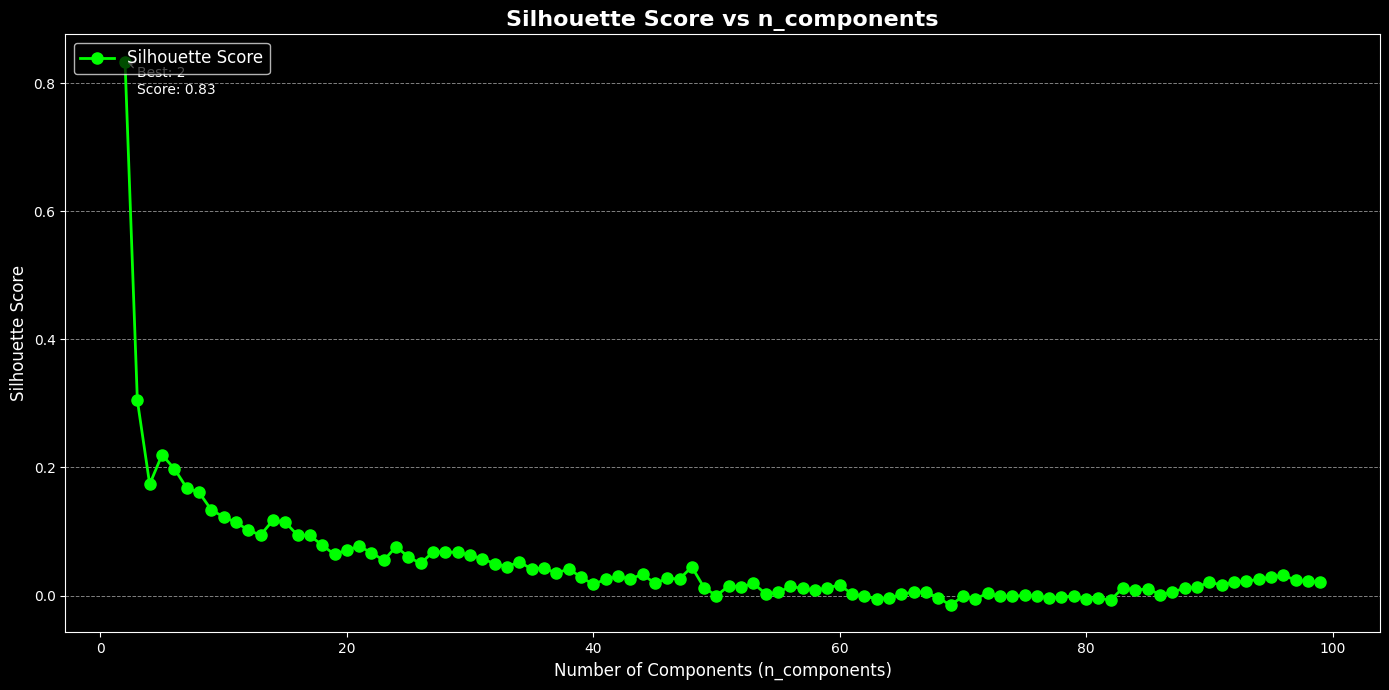

In [9]:
import matplotlib.pyplot as plt

# Data untuk plotting
n_components = list(results.keys())
silhouette_scores = [metrics['silhouette'] for metrics in results.values()]

# Ganti dengan style bawaan yang mirip
plt.style.use("dark_background")

# Membuat figure dengan nuansa grafik trading
plt.figure(figsize=(14, 7))

# Plot garis dengan marker
plt.plot(n_components, silhouette_scores, label="Silhouette Score", color="lime", linewidth=2, marker="o", markersize=8)

# Menambahkan grid horizontal
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)

# Menambahkan judul dan label
plt.title("Silhouette Score vs n_components", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Number of Components (n_components)", fontsize=12, color="white")
plt.ylabel("Silhouette Score", fontsize=12, color="white")

# Menambahkan anotasi untuk nilai maksimum
max_score = max(silhouette_scores)
best_n = n_components[silhouette_scores.index(max_score)]
plt.annotate(f"Best: {best_n}\nScore: {max_score:.2f}",
             xy=(best_n, max_score), xytext=(best_n + 1, max_score - 0.05),
             arrowprops=dict(facecolor='red', arrowstyle="->"),
             fontsize=10, color="white")

# Menambahkan legenda
plt.legend(fontsize=12, loc="upper left", facecolor="black", edgecolor="white", framealpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Clustering

Silhouette Score: 0.1682
Jumlah data pada setiap cluster:
Cluster
0    50
1    50
Name: count, dtype: int64


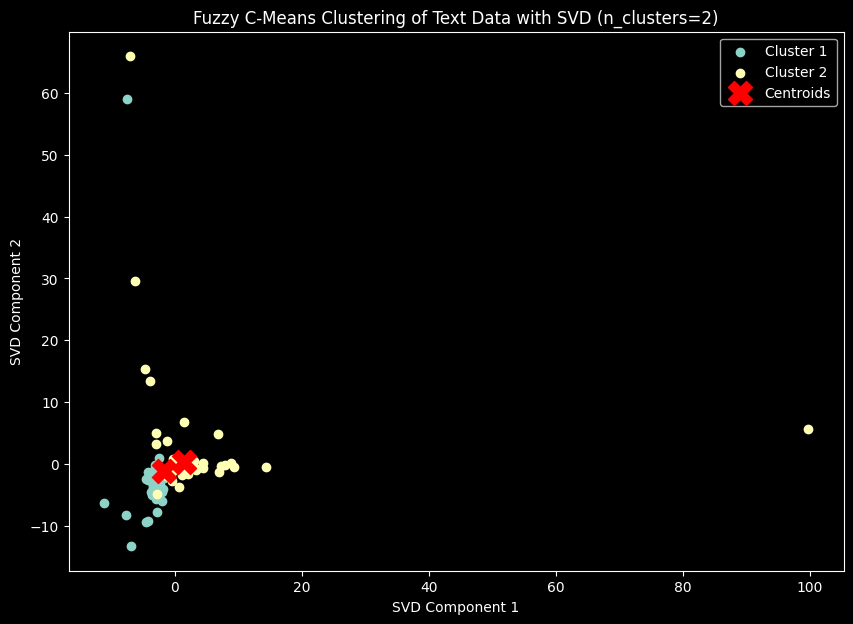

In [10]:
from fcmeans import FCM
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # Untuk manipulasi DataFrame

df = pd.read_csv("/content/drive/My Drive/ppw/report/tugas-ppw/data_preprocessing.csv")
data = df['stopword_removal']
random_seed = 42  # Tetapkan seed untuk konsistensi

# Step 2: Vektorisasi TF-IDF
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
tfidf = tfidf_matrix.toarray()

#Step 3 Normalisasi Hasil TF-IDF
scaler = StandardScaler()
data_normalisasi = scaler.fit_transform(tfidf)

# Step 4 : Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=7 , random_state=random_seed)
data_cluster = svd.fit_transform(data_normalisasi)



# Fuzzy C-Means Clustering
n_clusters = 2
fcm = FCM(n_clusters=n_clusters, m=2.0, max_iter=1000, epsilon=0.001, random_state=random_seed)
fcm.fit(data_cluster)

# Mendapatkan hasil clustering
membership = fcm.u
cluster_labels = np.argmax(membership, axis=1)  # Menentukan cluster untuk setiap data
# Tambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
# Tampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
# Tambahkan setelah cluster_labels dihasilkan
silhouette_avg = silhouette_score(data_cluster, cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.4f}")

# Cetak hasil jumlah data per cluster
print("Jumlah data pada setiap cluster:")
print(cluster_counts)


# Visualisasi hasil clustering
plt.figure(figsize=(10, 7))

# Plot titik data dalam ruang 2D yang sudah direduksi, dengan warna berdasarkan cluster
for i in range(n_clusters):
    plt.scatter(data_cluster[cluster_labels == i, 0],
                data_cluster[cluster_labels == i, 1], label=f'Cluster {i+1}')

# Plot centroid
cluster_centers = fcm.centers
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title(f'Fuzzy C-Means Clustering of Text Data with SVD (n_clusters={n_clusters})')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.legend()
plt.show()

In [11]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels
df

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal,kategori_encoded,Cluster
0,Awas! Kebiasaan Sepele Ini 26 Persen Lebih Tin...,"Rabu, 27 Nov 2024 19:02 WIB",Jakarta - Stroke merupakan salah satu kondisi ...,Kesehatan,Jakarta Stroke merupakan salah satu kondisi m...,jakarta stroke merupakan salah satu kondisi m...,"['jakarta', 'stroke', 'merupakan', 'salah', 's...",jakarta stroke salah kondisi medis menurunkan ...,0,0
1,"Berlebihan Makan Petai Bisa Picu Ginjal Rusak,...","Rabu, 27 Nov 2024 18:02 WIB",Jakarta - Petai atau parkia speciosa merupakan...,Kesehatan,Jakarta Petai atau parkia speciosa merupakan ...,jakarta petai atau parkia speciosa merupakan ...,"['jakarta', 'petai', 'atau', 'parkia', 'specio...",jakarta petai parkia speciosa tanaman asia ten...,0,0
2,"Pria Tertua di Dunia Meninggal di Usia 112, Su...","Rabu, 27 Nov 2024 16:52 WIB",Jakarta - Pria yang dinobatkan sebagai orang t...,Kesehatan,Jakarta Pria yang dinobatkan sebagai orang te...,jakarta pria yang dinobatkan sebagai orang te...,"['jakarta', 'pria', 'yang', 'dinobatkan', 'seb...",jakarta pria dinobatkan orang tertua dunia ver...,0,0
3,"Gejala Wasir (Ambeien), Penyebab, dan Cara Men...","Rabu, 27 Nov 2024 16:47 WIB",Jakarta - Wasir sama dengan ambeien. Keduanya ...,Kesehatan,Jakarta Wasir sama dengan ambeien Keduanya me...,jakarta wasir sama dengan ambeien keduanya me...,"['jakarta', 'wasir', 'sama', 'dengan', 'ambeie...",jakarta wasir ambeien nama penyakit hemoroid p...,0,0
4,"Jangan Abaikan Kelelahan, Catat Tips Biar Petu...","Rabu, 27 Nov 2024 16:03 WIB",Jakarta - Kelompok Penyelenggara Pemungutan Su...,Kesehatan,Jakarta Kelompok Penyelenggara Pemungutan Sua...,jakarta kelompok penyelenggara pemungutan sua...,"['jakarta', 'kelompok', 'penyelenggara', 'pemu...",jakarta kelompok penyelenggara pemungutan suar...,0,0
...,...,...,...,...,...,...,...,...,...,...
95,Triple Kill Jonatan Chrisite di China Masters:...,"Sabtu, 23 Nov 2024 15:04 WIB",Shenzhen - Jonatan Christie sukses menembus pa...,Olahraga,Shenzhen Jonatan Christie sukses menembus par...,shenzhen jonatan christie sukses menembus par...,"['shenzhen', 'jonatan', 'christie', 'sukses', ...",shenzhen jonatan christie sukses menembus part...,1,1
96,"China Masters 2024: Singkirkan Shi Yu Qi, Jona...","Sabtu, 23 Nov 2024 14:04 WIB",Jakarta - China Masters 2024 jalani babak semi...,Olahraga,Jakarta China Masters jalani babak semifinal...,jakarta china masters jalani babak semifinal...,"['jakarta', 'china', 'masters', 'jalani', 'bab...",jakarta china masters jalani babak semifinal j...,1,1
97,"Tangkal Judol, Menpora Mau Perbanyak Gelar Kej...","Sabtu, 23 Nov 2024 11:50 WIB",Jakarta - Kejuaraan Antarkampung (Tarkam) biki...,Olahraga,Jakarta Kejuaraan Antarkampung Tarkam bikinan...,jakarta kejuaraan antarkampung tarkam bikinan...,"['jakarta', 'kejuaraan', 'antarkampung', 'tark...",jakarta kejuaraan antarkampung tarkam bikinan ...,1,1
98,Vinales Bidik Rekor Ini Bersama Tech3,"Sabtu, 23 Nov 2024 10:50 WIB",Montmelo - Pebalap Tech3 KTM Maverick Vinales ...,Olahraga,Montmelo Pebalap Tech KTM Maverick Vinales op...,montmelo pebalap tech ktm maverick vinales op...,"['montmelo', 'pebalap', 'tech', 'ktm', 'maveri...",montmelo pebalap tech ktm maverick vinales opt...,1,1


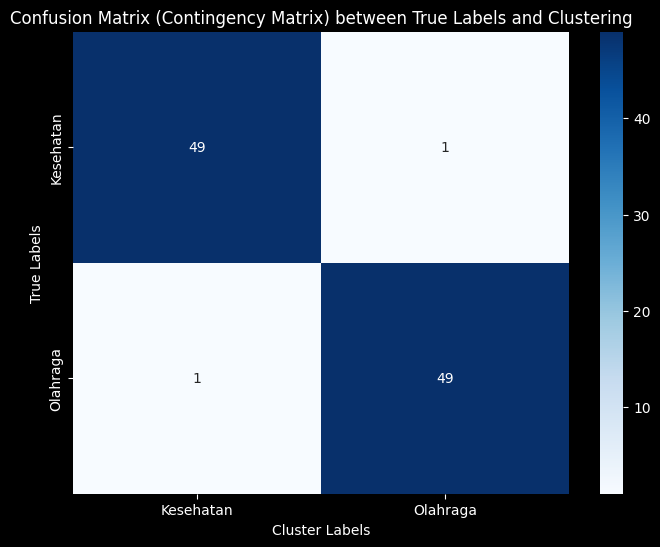

Confusion Matrix (Contingency Matrix):
[[49  1]
 [ 1 49]]


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil kolom kategori dari dataframe sebagai label asli (true labels)
true_labels = df['kategori']  # Ganti 'kategori' dengan nama kolom kategori di DataFrame Anda

# Gunakan LabelEncoder untuk mengubah kategori menjadi angka
label_encoder = LabelEncoder()
true_labels_encoded = label_encoder.fit_transform(true_labels)

# Hitung confusion matrix antara true labels dan hasil clustering
conf_matrix = confusion_matrix(true_labels_encoded, cluster_labels)

# Tampilkan confusion matrix menggunakan heatmap untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Contingency Matrix) between True Labels and Clustering')
plt.xlabel('Cluster Labels')
plt.ylabel('True Labels')
plt.show()

# Cetak confusion matrix secara numerik
print("Confusion Matrix (Contingency Matrix):")
print(conf_matrix)

In [13]:
# Tambahkan kolom ID jika belum ada
df['id'] = df.index

# Ambil kolom id, kategori_encoded, dan Cluster
selected_columns = df[['id', 'kategori_encoded', 'Cluster']]

# Tampilkan DataFrame yang hanya berisi kolom yang dipilih
print(selected_columns)

# Ambil semua anggota Cluster 0
cluster_0 = selected_columns[selected_columns['Cluster'] == 0]['id'].tolist()

# Ambil semua anggota Cluster 1
cluster_1 = selected_columns[selected_columns['Cluster'] == 1]['id'].tolist()

# Tampilkan hasil dalam bentuk list
print("Anggota Cluster 0:", cluster_0)
print("Anggota Cluster 1:", cluster_1)

    id  kategori_encoded  Cluster
0    0                 0        0
1    1                 0        0
2    2                 0        0
3    3                 0        0
4    4                 0        0
..  ..               ...      ...
95  95                 1        1
96  96                 1        1
97  97                 1        1
98  98                 1        1
99  99                 1        1

[100 rows x 3 columns]
Anggota Cluster 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 91]
Anggota Cluster 1: [10, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99]
